# HairNet Compliance Detection 

Dataset Download & Exploration

**Dataset:** [Roboflow — HairNet Compliance Detection](https://app.roboflow.com/yolo-training-ywjft/hairnet-compliance-detection)  

## Install Dependencies

In [2]:
!pip install roboflow ultralytics mlflow opencv-python matplotlib seaborn pandas pillow pyyaml python-dotenv -q


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports & Setup

In [4]:
import sys
import os
import random
from pathlib import Path
from collections import defaultdict

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
from PIL import Image
from dotenv import load_dotenv

# Detect Google Colab
ON_COLAB = 'google.colab' in sys.modules
print(f'Running on Colab: {ON_COLAB}')

# Load .env from the project root
load_dotenv(Path('.env'))

RF_API_KEY = os.getenv('RF_API_KEY')
RF_WORKSPACE = os.getenv('RF_WORKSPACE')
RF_PROJECT = os.getenv('RF_PROJECT')
RF_VERSION = int(os.getenv('RF_VERSION', '1'))

assert RF_API_KEY, "RF_API_KEY not found — check your .env file"
print(f'Workspace : {RF_WORKSPACE}')
print(f'Project   : {RF_PROJECT}')
print(f'Version   : {RF_VERSION}')

# Output folder for EDA figures
OUTPUT_DIR = Path('outputs/eda')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='Set2')
print('Setup complete.')

Running on Colab: False
Workspace : yolo-training-ywjft
Project   : hairnet-compliance-detection
Version   : 1
Setup complete.


## 2. Connect to Roboflow API

In [5]:
import requests

BASE_URL = f'https://api.roboflow.com/{RF_WORKSPACE}/{RF_PROJECT}'
PARAMS = {'api_key': RF_API_KEY}

resp = requests.get(BASE_URL, params=PARAMS)
resp.raise_for_status()
project_data = resp.json()

print('Connected to Roboflow API ✓')
print(f'Project : {project_data["project"]["name"]}')
print(f'License : {project_data["project"]["license"]}')
print(f'Type    : {project_data["project"]["type"]}')

Connected to Roboflow API ✓
Project : HairNet Compliance Detection
License : CC BY 4.0
Type    : object-detection


## 3. Project Overview

In [15]:
print(project_data)

{'workspace': {'name': 'yolo training', 'url': 'yolo-training-ywjft', 'members': 1}, 'project': {'id': 'yolo-training-ywjft/hairnet-compliance-detection', 'type': 'object-detection', 'name': 'HairNet Compliance Detection', 'created': 1746435626.235, 'updated': 1778678614.236, 'images': 423, 'unannotated': 0, 'annotation': 'hairnet', 'versions': 0, 'public': True, 'multilabel': False, 'license': 'CC BY 4.0', 'splits': {'train': 283, 'valid': 93, 'test': 47}, 'colors': {'hairnet': '#C7FC00', 'person': '#8622FF', 'No hairnet': '#FE0056'}, 'classes': {'hairnet': 1325, 'No hairnet': 2065, 'person': 3429}, 'icon': {'original': 'https://source.roboflow.com/WJCwGasLiCSum3dP0s9EVWFxM6j2/2hCjt3C28ma6I183cqPh/original.jpg', 'thumb': 'https://source.roboflow.com/WJCwGasLiCSum3dP0s9EVWFxM6j2/2hCjt3C28ma6I183cqPh/thumb.jpg', 'annotation': 'https://source.roboflow.com/WJCwGasLiCSum3dP0s9EVWFxM6j2/2hCjt3C28ma6I183cqPh/annotation-hairnet.png'}, 'preprocessing': {}, 'augmentation': {}}, 'versions': []}


In [8]:
proj = project_data['project']
CLASS_NAMES = list(proj['classes'].keys())
classes = proj['classes']  

print(f"{'Class':<20} {'Annotations':>12}")
print('-' * 34)
for cls, count in classes.items():
    print(f"{cls:<20} {count:>12,}")
print()

splits_info = proj['splits']
print(f"{'Split':<10} {'Images':>8}")
print('-' * 20)
for split, count in splits_info.items():
    print(f"{split:<10} {count:>8}")

Class                 Annotations
----------------------------------
hairnet                     1,325
No hairnet                  2,065
person                      3,429

Split        Images
--------------------
train           283
valid            93
test             47


## 4. Split Counts

Split        Images   % of total
--------------------------------
train           283        66.9%
valid            93        22.0%
test             47        11.1%
TOTAL           423


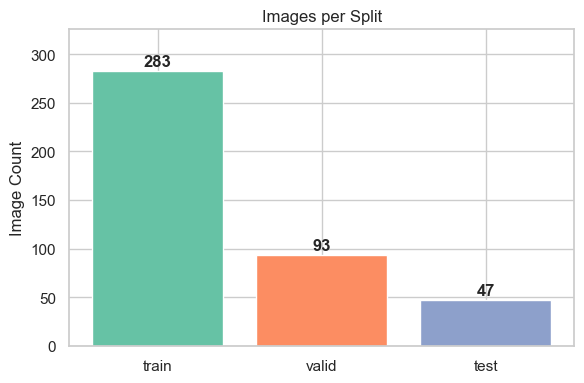

Saved → outputs\eda/split_counts.png


In [7]:
splits_info = proj['splits']
total = sum(splits_info.values())

print(f"{'Split':<10} {'Images':>8} {'% of total':>12}")
print('-' * 32)
for split, cnt in splits_info.items():
    print(f"{split:<10} {cnt:>8} {cnt/total*100:>11.1f}%")
print(f"{'TOTAL':<10} {total:>8}")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(splits_info.keys(), splits_info.values(), color=sns.color_palette('Set2', 3))
for bar, cnt in zip(bars, splits_info.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(cnt),
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Images per Split')
ax.set_ylabel('Image Count')
ax.set_ylim(0, max(splits_info.values()) * 1.15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'split_counts.png', dpi=150)
plt.show()
print(f'Saved → {OUTPUT_DIR}/split_counts.png')

## 5. Class Distribution

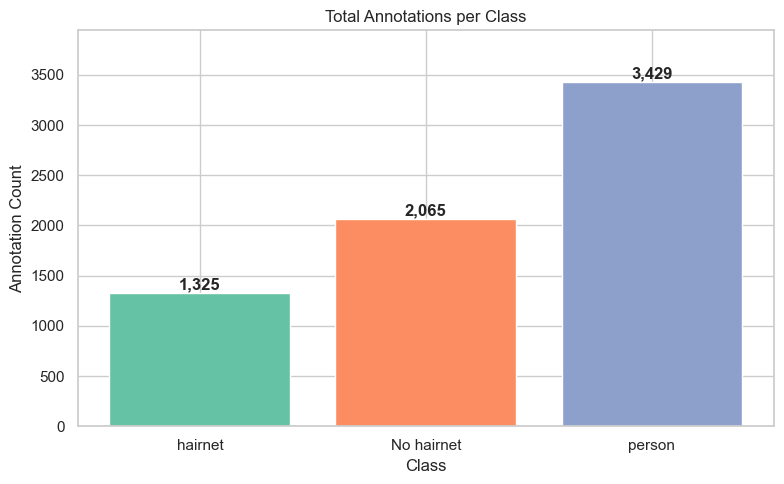

Saved → outputs\eda/class_distribution.png

Class imbalance — no_hairnet / hairnet ratio: 1.56x
→ Consider class-weighted loss or augmentation for the minority class.


In [11]:
classes = proj['classes']
class_names = list(classes.keys())
class_counts = list(classes.values())

fig, ax = plt.subplots(figsize=(8, 5))
palette = sns.color_palette('Set2', len(class_names))
bars = ax.bar(class_names, class_counts, color=palette)
for bar, cnt in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{cnt:,}',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Total Annotations per Class')
ax.set_xlabel('Class')
ax.set_ylabel('Annotation Count')
ax.set_ylim(0, max(class_counts) * 1.15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150)
plt.show()
print(f'Saved → {OUTPUT_DIR}/class_distribution.png')

# Imbalance check
counts_lower = {k.lower().replace(' ', '_'): v for k, v in classes.items()}
hairnet = counts_lower.get('hairnet', 0)
no_hairnet = counts_lower.get('no_hairnet', 0)
if hairnet > 0 and no_hairnet > 0:
    print(f'\nClass imbalance — no_hairnet / hairnet ratio: {no_hairnet / hairnet:.2f}x')
    print('→ Consider class-weighted loss or augmentation for the minority class.')